In [ ]:
# import libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import BytesIO
from PIL import Image

In [ ]:
# Define the path and filename separately (evaluators can adjust to their specific path)
path = r"C:\Users\Faiyza\OneDrive - University of Toronto\Old Desktop\DSI\visualization\02_activities\assignments"
filename = "university_enrolment_headcount_2022-23.csv"

# Join the path and filename into a full path
full_path = os.path.join(path, filename)

# Read the CSV into a DataFrame
df = pd.read_csv(full_path)

# Change the headcount to numeric, because I think it's reading it as a string
# Also, there are "*" values. To avoid, use errors = 'coerce' which will handle them as NAN
df['HEADCOUNT'] = pd.to_numeric(df['HEADCOUNT'], errors='coerce')

# Filter for only the undergrads, because I want to focus on them
df_undergrad = df[df['Study Level'] == 'Undergraduate']

# Filter for only male and female, since most entries in "N/A or Another" are blank and will not be useful
df_gender = df_undergrad[
    (df_undergrad['Gender Group'] == 'Female') |
    (df_undergrad['Gender Group'] == 'Male')]

# Checking the first few rows 
print(df_gender.head())

  Institution Fiscal Year    Study Level Gender Group  HEADCOUNT
0      Algoma   2012-2013  Undergraduate       Female      569.0
1      Algoma   2012-2013  Undergraduate         Male      539.0
2      Algoma   2013-2014  Undergraduate       Female      570.0
3      Algoma   2013-2014  Undergraduate         Male      648.0
4      Algoma   2014-2015  Undergraduate       Female      559.0


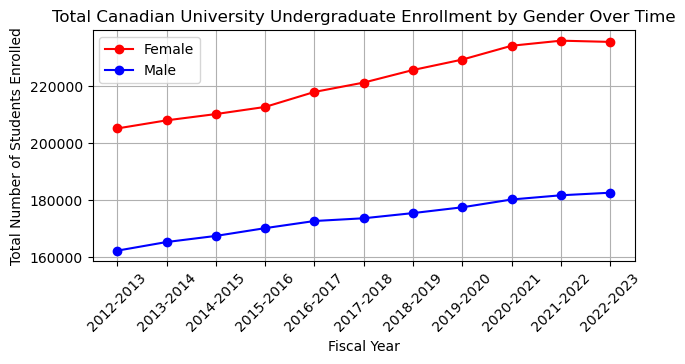

In [190]:
# I want two graphs: 
# 1. I want the TOTAL number of male and female students enrolled across ALL universities in Canada for every fiscal year
# 2. I want the RATE OF CHANGE of male and female students enrolled across ALL universities in Canada for every fiscal year 


# Let's do 1 first.

# First, let's group each university by fiscal year AND gender group, summing the headcounts 
# Seems if I don't put "reset_index()" then it becomes a series object, which didn't work with the graphs
# And if I then do "to_frame()" to convert that series it doesn't give the "male" the fiscal year which makes problems with graphing...
# So "reset_index" helps to bring the old index back after using sum
df_gender_year_sum = df_gender.groupby(['Fiscal Year', 'Gender Group'])['HEADCOUNT'].sum().reset_index()

#print(df_gender_year_sum)

# Now I want my graph values
# I want fiscal year on x-axis, and total count for male and female, seperately, on y-axis

# I need to do .unique() because otherwise it gives two of each, one for each male and female
fiscal_year = df_gender_year_sum['Fiscal Year'].unique()
#print(fiscal_year)

# Here are the female counts only
female_df = df_gender_year_sum[df_gender_year_sum['Gender Group'] == 'Female']
#print(female_counts)

# Now let's take the headcount column
female_counts = female_df["HEADCOUNT"].to_list()
#print(female_counts)

# Same for male
male_df = df_gender_year_sum[df_gender_year_sum['Gender Group'] == 'Male']
male_counts = male_df["HEADCOUNT"].to_list()
#print(male_counts)

# Now to test our plot
plt.figure(figsize=(7, 3))
plt.plot(fiscal_year, female_counts, label='Female', marker='o', color='red')
plt.plot(fiscal_year, male_counts, label='Male', marker='o', color='blue')

# Adjust plot details
plt.title('Total Canadian University Undergraduate Enrollment by Gender Over Time')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Number of Students Enrolled')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()


# Very nice. 

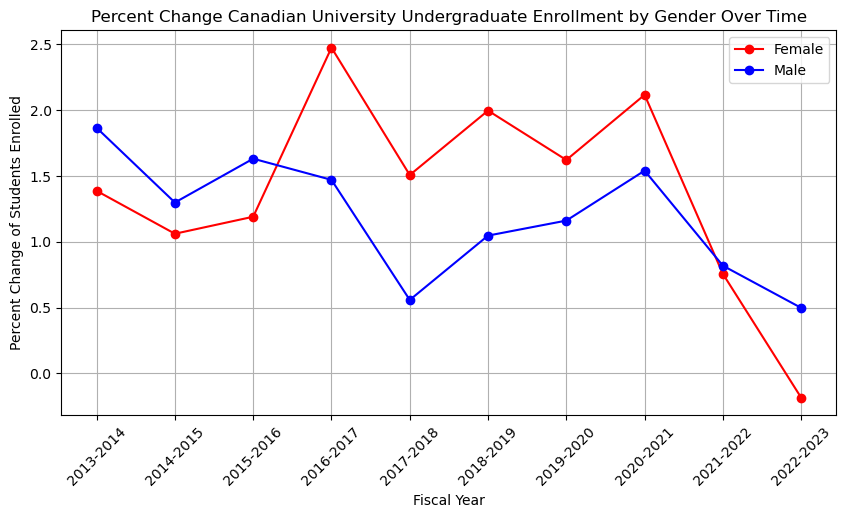

In [ ]:
# This above graph is quite nice. It shows that in general male and female enrollment keeps increasing, perhaps because population keeps increasing
# However, what is happening to the rate of change? Are they changing at the same time? Any significant events?
# So this brings us to #2: I want the RATE OF CHANGE of male and female students enrolled across ALL universities in Canada for every fiscal year 

# From above, we have the female and male headcounts per fiscal year
#print(female_df)
#print(male_df)

# Let's now get the total change
female_rate = female_df['HEADCOUNT'].pct_change() * 100
male_rate = male_df['HEADCOUNT'].pct_change() * 100

# Plot the figure
plt.figure(figsize=(10, 5))
plt.plot(fiscal_year, female_rate, label='Female', marker='o', color='red')
plt.plot(fiscal_year, male_rate, label='Male', marker='o', color='blue')

# Adjust plot details
plt.title('Percent Change Canadian University Undergraduate Enrollment by Gender Over Time')
plt.xlabel('Fiscal Year')
plt.ylabel('Percent Change of Students Enrolled')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

# Very nice. 

Text(2013-2014, 0.05, 'with decreased enrollment for the first time ')

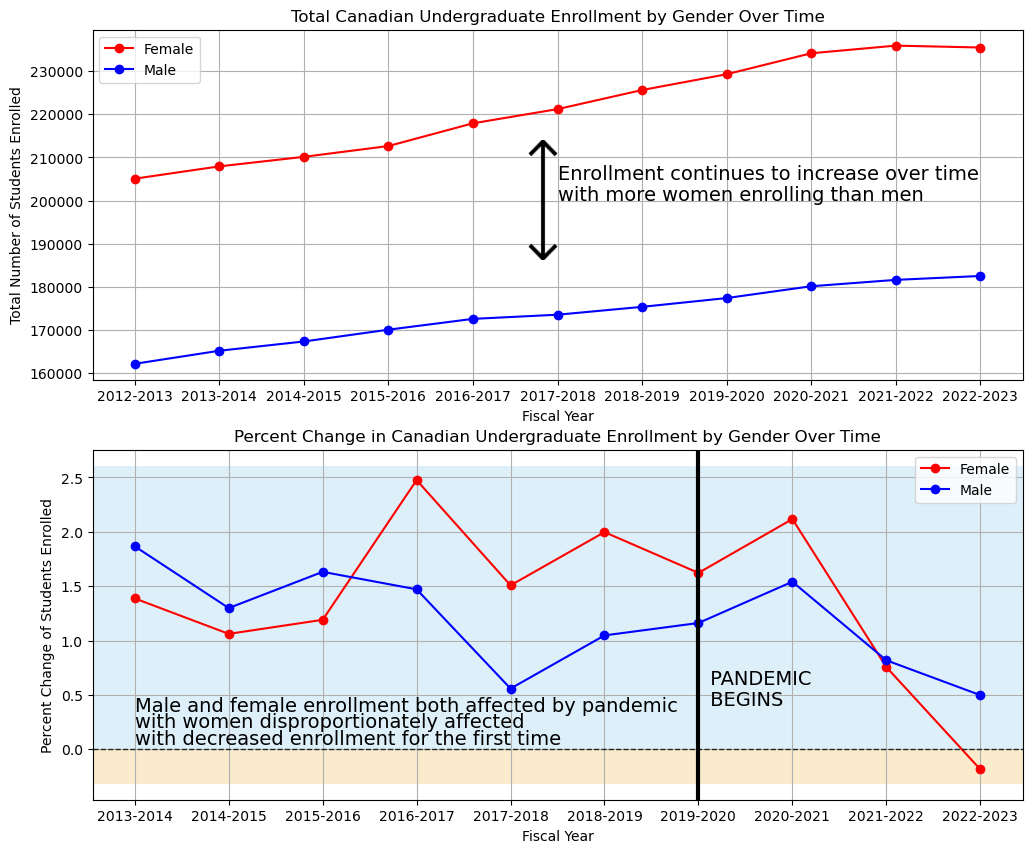

In [ ]:
# Let's now mix these figures into one, creating a nice viz

# Want subplots, so defining two ax objects
fig, (ax1, ax2) = plt.subplots(ncols=1,
                               nrows=2,
                               figsize=(12,10))
font = {'family':'sans-serif'}

# FIRST FIGURE _______________________________________________________________________
# ax1 will be the total enrollment graph 
ax1.plot(fiscal_year, female_counts, label='Female', marker='o', color='red')
ax1.plot(fiscal_year, male_counts, label='Male', marker='o', color='blue')

# Adjust plot details
ax1.set_title('Total Canadian Undergraduate Enrollment by Gender Over Time', fontdict=font)
ax1.set_xlabel('Fiscal Year',fontdict=font)
ax1.set_ylabel('Total Number of Students Enrolled',fontdict=font)
ax1.grid(True)
ax1.legend()

# I want to put a vertical double arrow on this plot. Let's follow the steps from lecture.

# Get image from internet
response = requests.get('https://www.shareicon.net/data/128x128/2016/04/20/752388_arrows_512x512.png')
image_file = BytesIO(response.content)
image = Image.open(image_file)

# NOW we are OVERLAYING a new axis (ax1_image) on our figure to act as a container for our image
ax1_image = fig.add_axes([0.45, # x coordinate(ON FIGURE, NOT AXES)
                         0.51, # y coordinate (ON FIGURE, NOT AXES)
                         0.10, # image width
                         0.40]) # image height

# Now we want to add our image and then get rid of that axis border
ax1_image.imshow(image)
ax1_image.axis('off')

# weeee

# Now let's add text onto this plot next to the arrow. 
# This is the message
ax1.text(fiscal_year[5], 205000, "Enrollment continues to increase over time",fontsize=14,fontdict=font)
ax1.text(fiscal_year[5], 200000, "with more women enrolling than men",fontsize=14,fontdict=font)

# SECOND FIGURE _______________________________________________________________________

# ax2 will be the percent change
ax2.plot(fiscal_year, female_rate, label='Female', marker='o', color='red')
ax2.plot(fiscal_year, male_rate, label='Male', marker='o', color='blue')

# Adjust plot details
ax2.set_title('Percent Change in Canadian Undergraduate Enrollment by Gender Over Time',fontdict=font)
ax2.set_xlabel('Fiscal Year',fontdict=font)
ax2.set_ylabel('Percent Change of Students Enrolled',fontdict=font)
ax2.grid(True)
ax2.legend()

# Colour the graph
# negative change = orange
ax2.axhspan(ymin, 0, facecolor='#E69F00', alpha=0.2)  # soft bluish-gray
# positive change = blue
ax2.axhspan(0, ymax, facecolor='#56B4E9', alpha=0.2)  # warm beige-gray
# Add a horizontal line at y=0
ax2.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.8)

# I want to write in the covid period onto this graph
ax2.axvline(x='2019-2020', linestyle='-', color='black', linewidth=3)
ax2.text(fiscal_year[7], 0.6, "  PANDEMIC",fontsize=14,fontdict=font)
ax2.text(fiscal_year[7], 0.4, "  BEGINS",fontsize=14,fontdict=font)

# Message
ax2.text(fiscal_year[1], 0.35, "Male and female enrollment both affected by pandemic",fontsize=14,fontdict=font)
ax2.text(fiscal_year[1], 0.20, "with women disproportionately affected",fontsize=14,fontdict=font)
ax2.text(fiscal_year[1], 0.05, "with decreased enrollment for the first time ",fontsize=14,fontdict=font)




